In [1]:
import dataset # local import
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

seed = 123
df = dataset.read_agg(month_start=1, month_end=12)
# print(df.info())
# print(df.head(3))

reading data for month 1
reading data for month 2
reading data for month 3
reading data for month 4
reading data for month 5
reading data for month 6
reading data for month 7
reading data for month 8
reading data for month 9
reading data for month 10
reading data for month 11
reading data for month 12
collecting weather data


/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:297: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('T', 0, inplace=True)
/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:298: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('M', np.nan, inplace=True)


collecting calendar data


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5128903 entries, 0 to 5128902
Data columns (total 19 columns):
 #   Column            Dtype   
---  ------            -----   
 0   pickup_month      int32   
 1   pickup_dow        int32   
 2   time_of_day       category
 3   pickup_zone       category
 4   route             category
 5   total_ride_count  int64   
 6   temp_high         int64   
 7   precip            float64 
 8   snow              float64 
 9   max_wind_speed    float64 
 10  cloud_coverage    float64 
 11  fog               bool    
 12  low_vis           bool    
 13  thunder           bool    
 14  hail              bool    
 15  freezing_rain     bool    
 16  haze              bool    
 17  holiday           category
 18  lag_demand        float64 
dtypes: bool(6), category(4), float64(5), int32(2), int64(2)
memory usage: 367.5 MB


In [2]:
import pandas as pd

# No need for categorical ordering or complex sorting
daily = df.groupby(['pickup_date', 'time_of_day', 'route'], as_index=False)['total_ride_count'].sum()

# Sort by date to ensure proper shift across days
daily = daily.sort_values(['route', 'time_of_day', 'pickup_date'])

# Lag: same time_of_day, previous day
daily['lag_demand'] = daily.groupby(['route', 'time_of_day'])['total_ride_count'].shift(1)

# Check result
daily[daily['route'] == "Upper East Side North to Upper East Side South"]
df = df.merge(
    daily[['route', 'pickup_date', 'time_of_day', 'lag_demand']],
    on=['time_of_day', 'route', 'pickup_date'],
    how='left'
)
df['lag_demand'] = df['lag_demand'].fillna(0)

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Recast object types -> category (just to be sure)
df = df.astype({
    'pickup_zone': 'category',
    'route': 'category',
    'time_of_day': 'category',
    'hail': 'bool',  
    'freezing_rain': 'bool',  
    'holiday': 'category',
})

# Remove waste columns
df['precip'] = df['total_ride_count'] * df['precip']
df['temp_high'] = df['total_ride_count'] * df['temp_high']
df = df.drop(errors='ignore', columns=[
    # 'lag_demand',
    'dropoff_zone',
    'pickup_date',
    'service_route',
    'pickup_service_zone',
    'dropoff_service_zone',
    'pickup_week',
    'pickup_day',  
    'avg_fare_amount',        
    # 'hail',
    # 'freezing_rain',
    # 'haze',

])
# df = df[df['total_ride_count'] >= 40]

# These columns only have a few categories
#
# => onehot encoding is okay
columns_to_onehot_encode = [
    'pickup_dow',
    'time_of_day',
]

# These columns have LOADS of categories
#
# => ordinal encoding is needed             <---- not doing this gives 500GB encoded dataset
#``
# (tried TargetEncoder, but still ended up at 22GB - sticking to ordinal)
columns_to_ordinal_encode = [
    'pickup_zone',
    'route',
    'holiday',
]



# Split `y` BEFORE pipeline
# scaler = StandardScaler()
# y = scaler.fit_transform(df['total_ride_count'].values.reshape(-1, 1))
y = df['total_ride_count']
X = df.drop(columns=['total_ride_count'])

# scaler_lag = StandardScaler()
# X['lag_demand'] = scaler_lag.fit_transform(X['lag_demand'])

# Pipeline
#
# Transfroms the categorical columns to onehot-encoded types
pipeline = ColumnTransformer(
    transformers=[
        #                               +--- `sparse_output=True` stops the encoder duplicating data
        #                               |
        ("onehot", OneHotEncoder(sparse_output=True), columns_to_onehot_encode), 
        ("ordinal", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_ordinal_encode),
    ],
    remainder='passthrough'
)
# pipeline.set_output(transform='pandas') # returning pandas cost too much memory
X_encoded = pipeline.fit_transform(X)

# Train vs Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=seed)

# Train vs Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=seed)

In [9]:
from lightgbm import LGBMRegressor

lg = LGBMRegressor(
    random_state=seed,
    learning_rate=0.01,
    n_estimators=1000,
    num_leaves=60, # default=31
    max_depth=-1,
    min_child_samples=20, # default=20
    # subsample_for_bin=50_000, # default=200_000

    # The type of feature importance to be filled into feature_importances_. If ‘split’, result contains numbers of times the feature is used in a model. 
    #
    # If ‘gain’, result contains total gains of splits which use the feature.
    # importance_type='split',
    importance_type='gain',
)
lg.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.121435 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1116
[LightGBM] [Info] Number of data points in the train set: 2872185, number of used features: 27
[LightGBM] [Info] Start training from score 6.861329


,boosting_type,'gbdt'
,num_leaves,60
,max_depth,-1
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


/nix/store/pdk4ffqv9n70af48rdll1rqlr0ddnvdw-python3-3.12.13-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Mean Absolute Error: 	0.3739
Mean Squared Error: 	1.6139
R squared: 		0.9903


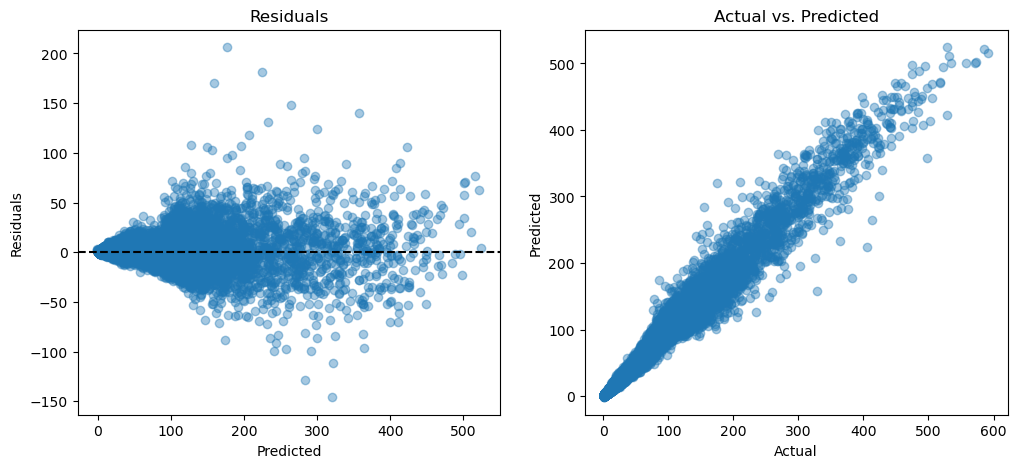

In [10]:
import helpers

training_predictions = lg.predict(X_train)
helpers.analysis(y_train, training_predictions)

/nix/store/pdk4ffqv9n70af48rdll1rqlr0ddnvdw-python3-3.12.13-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Mean Absolute Error: 	0.3813
Mean Squared Error: 	1.9857
R squared: 		0.9879


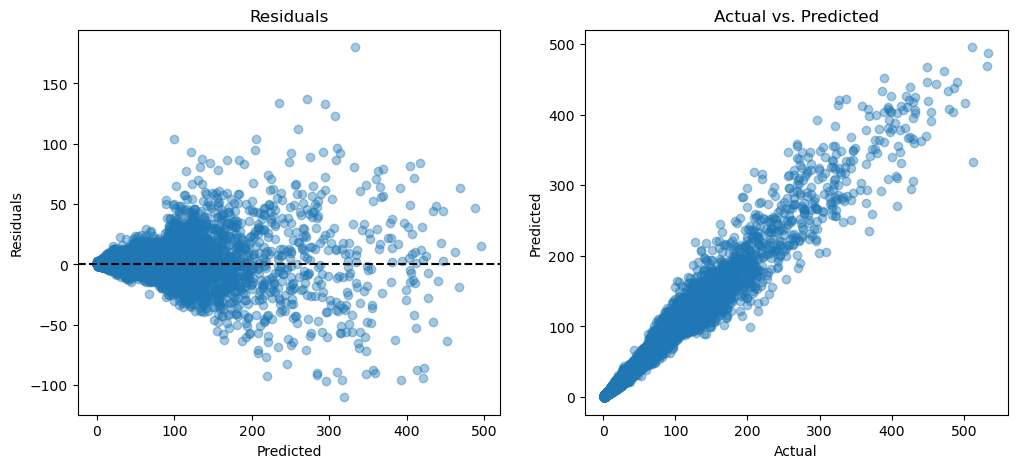

In [11]:
validation_predictions = lg.predict(X_val)
helpers.analysis(y_val, validation_predictions)

                             feature    importance
16              remainder__temp_high  2.006041e+10
27             remainder__lag_demand  2.484696e+09
15           remainder__pickup_month  7.875108e+08
20         remainder__cloud_coverage  9.286888e+07
19         remainder__max_wind_speed  8.352731e+07
0               onehot__pickup_dow_0  4.826729e+07
1               onehot__pickup_dow_1  4.600971e+07
17                 remainder__precip  4.575361e+07
5               onehot__pickup_dow_5  3.485922e+07
4               onehot__pickup_dow_4  2.764741e+07
18                   remainder__snow  2.416844e+07
2               onehot__pickup_dow_2  1.787807e+07
13                    ordinal__route  1.466367e+07
6               onehot__pickup_dow_6  1.359545e+07
12              ordinal__pickup_zone  1.279904e+07
3               onehot__pickup_dow_3  9.143308e+06
23                remainder__thunder  8.064632e+06
21                    remainder__fog  6.687249e+06
26                   remainder_

<Figure size 1200x1200 with 0 Axes>

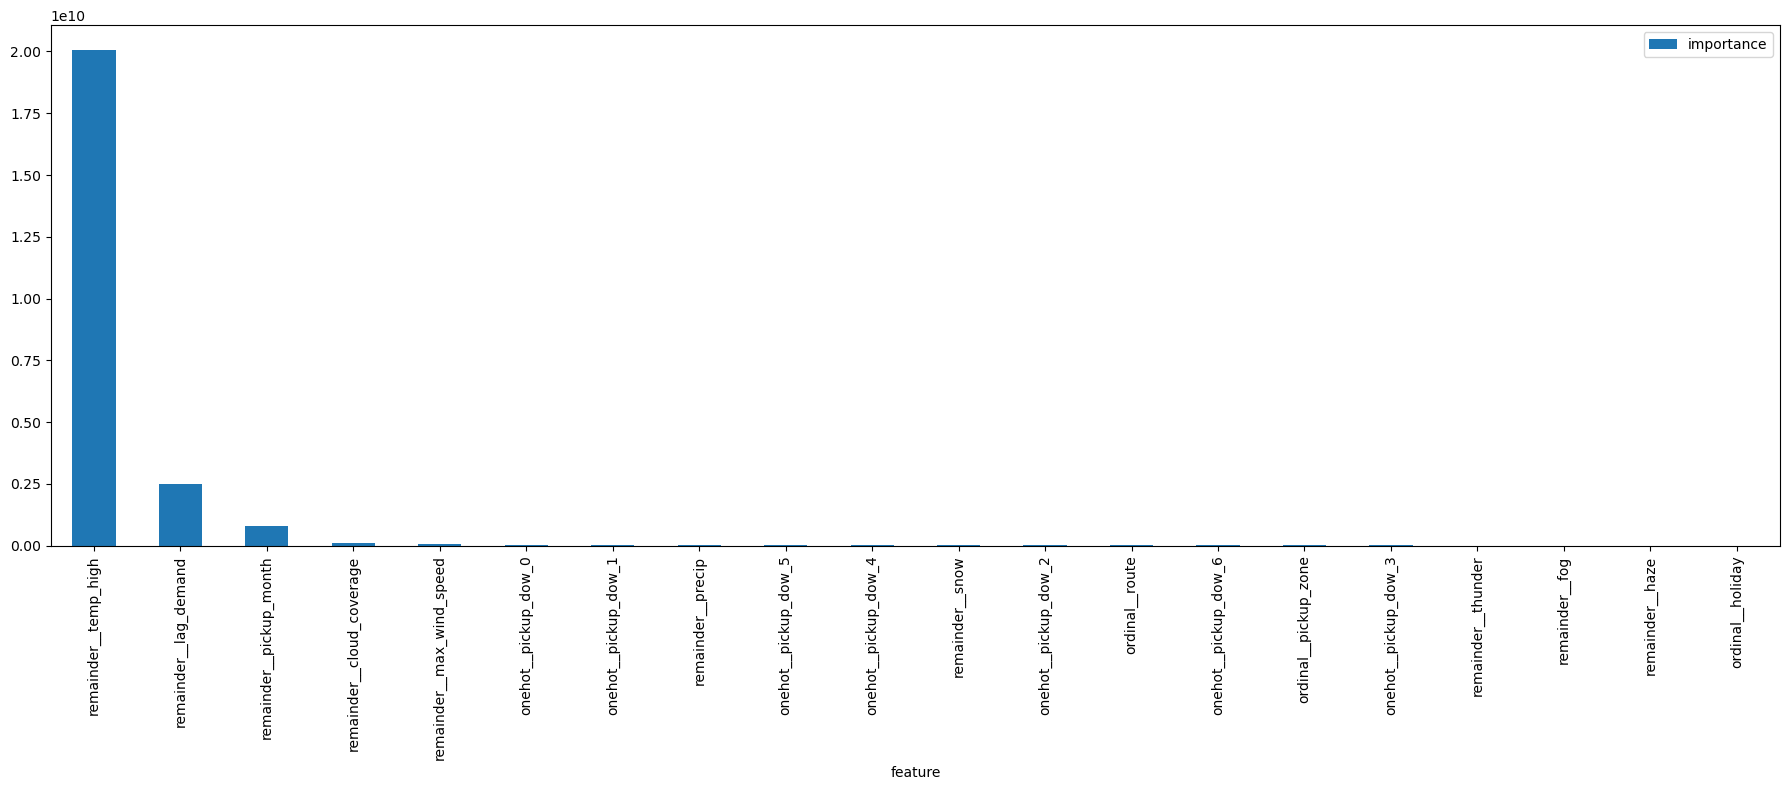

In [12]:
feature_names = pipeline.get_feature_names_out()
importances = lg.feature_importances_
feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
print(feat_df)

plt.figure(figsize=(12,12))
feat_df.head(20).plot(kind='bar', x='feature', y='importance', figsize=(18, 8))
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

/nix/store/pdk4ffqv9n70af48rdll1rqlr0ddnvdw-python3-3.12.13-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Mean Absolute Error: 	0.3780
Mean Squared Error: 	1.7819
R squared: 		0.9892


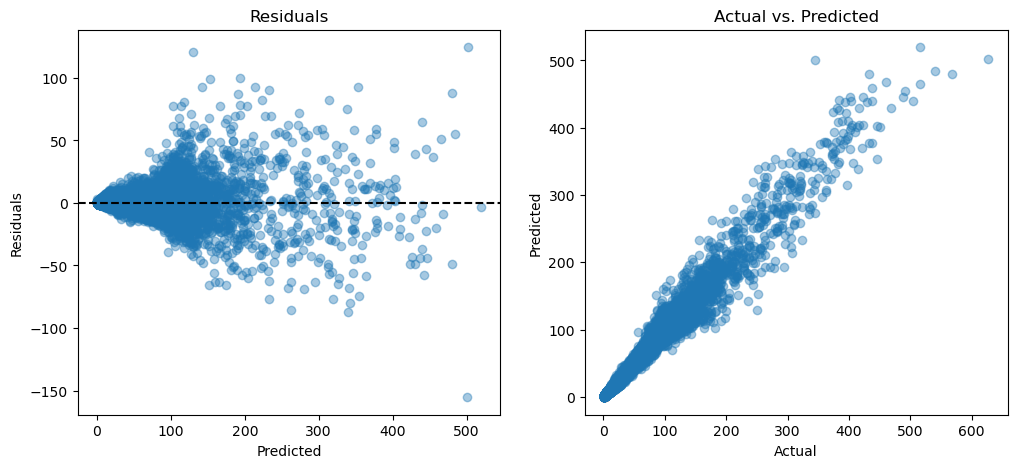

In [13]:
test_predictions = lg.predict(X_test)
helpers.analysis(y_test, test_predictions)